In [1]:
print("Here begins the data overview notebook.")

Here begins the data overview notebook.


In [2]:
# Student Mental Health – Data Overview & Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset, set display options, show first few rows
pd.set_option("display.max_columns", None)

df = pd.read_csv("../../data/raw/student_mental_health/student_depression.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
#Print information about the dataset
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

Shape: (27901, 18)

Column types:
id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness             str
Depression                                 int64
dtype: object


In [4]:
#Print summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


In [5]:
# Variable semantics, save summary to CSV
variable_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

variable_summary.sort_values("missing_pct", ascending=False)
variable_summary.to_csv("../outputs/tables/mental_health_student_depression_variable_summary.csv", index=False)

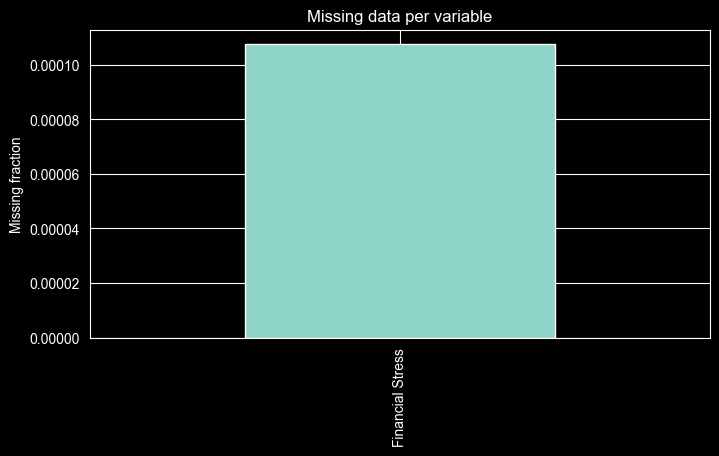

In [6]:
# Missing data analysis
missing = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing[missing > 0].plot(kind="bar")
plt.ylabel("Missing fraction")
plt.title("Missing data per variable")
plt.show()

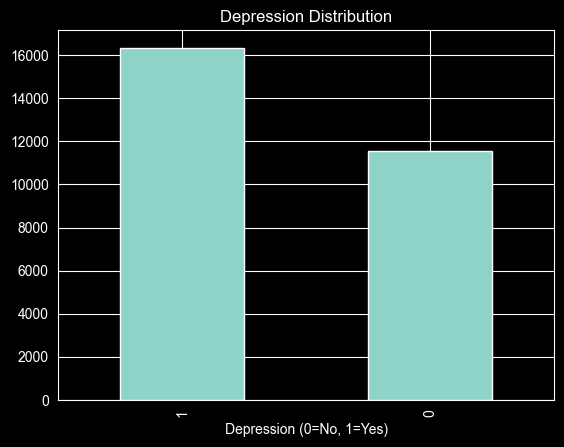

In [2]:
# Exploratory Plots
# Depression distribution - target variable
df["Depression"].value_counts().plot(kind="bar")
plt.title("Depression Distribution")
plt.xlabel("Depression (0=No, 1=Yes)")
plt.show()

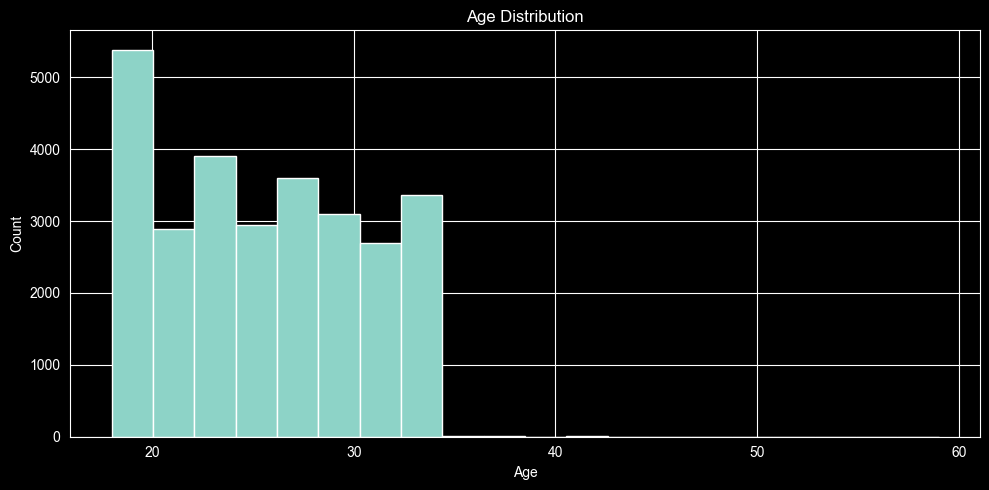

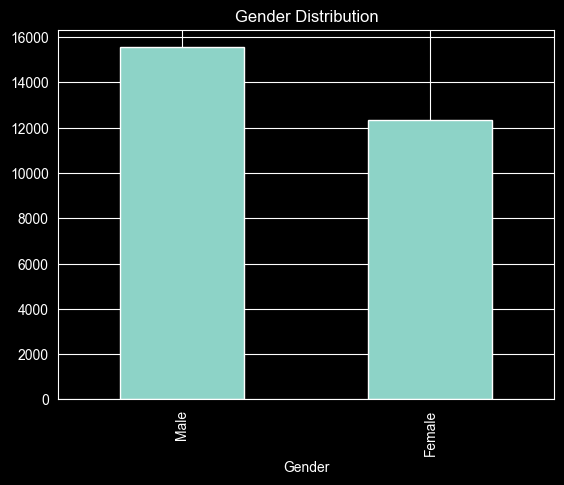

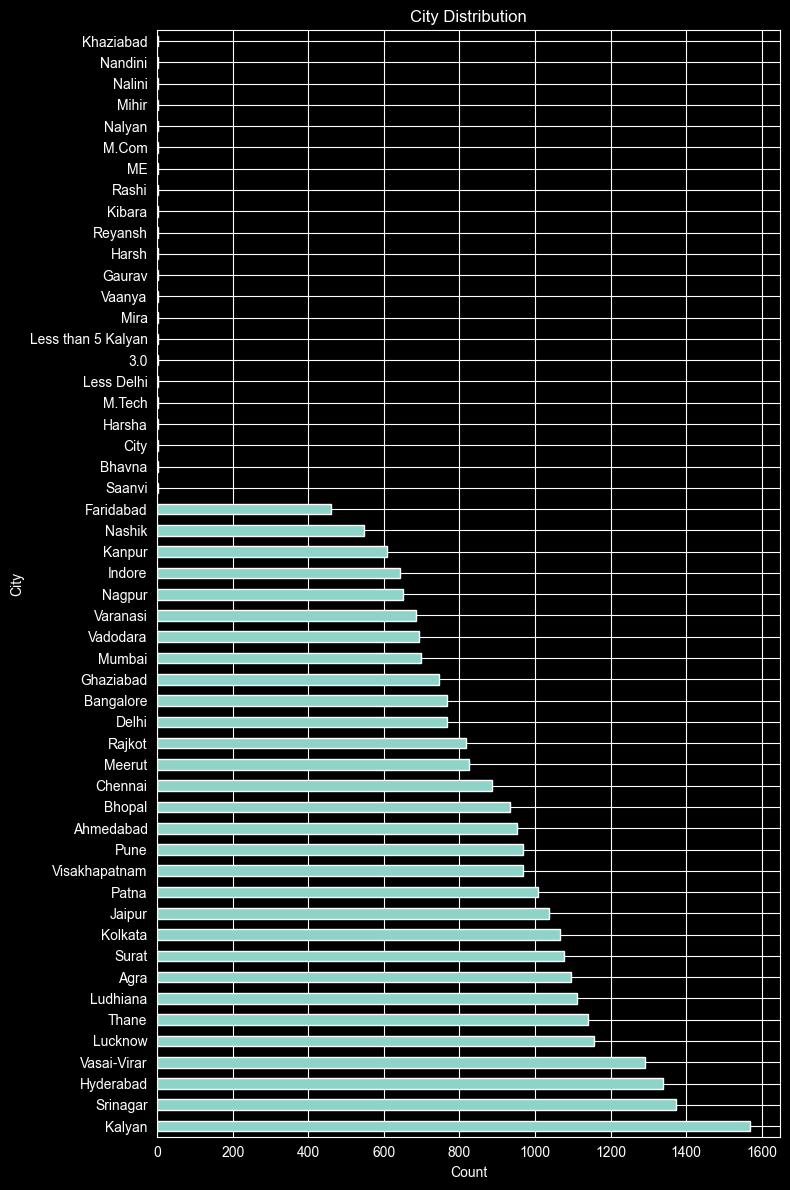

In [7]:
# Age distribution
plt.figure(figsize=(10,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Gender
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.show()


# City distribution
city_counts = df["City"].value_counts()
plt.figure(figsize=(8,12))
city_counts.plot(kind="barh")
plt.title("City Distribution")
plt.xlabel("Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()


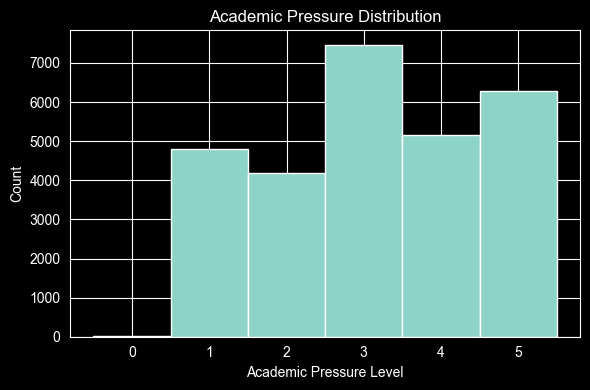

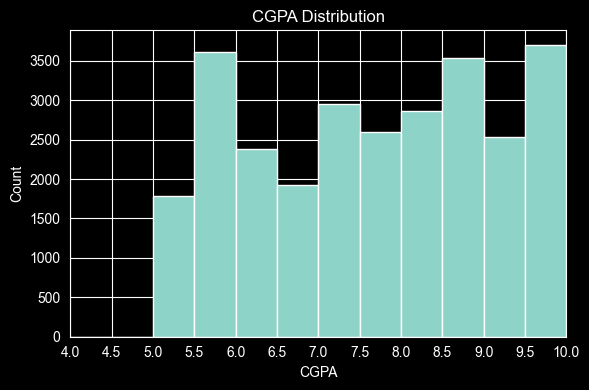

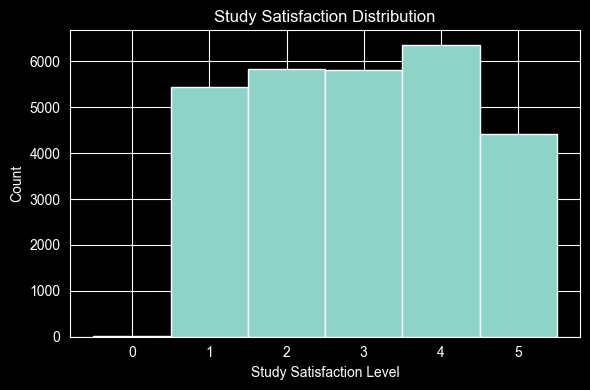

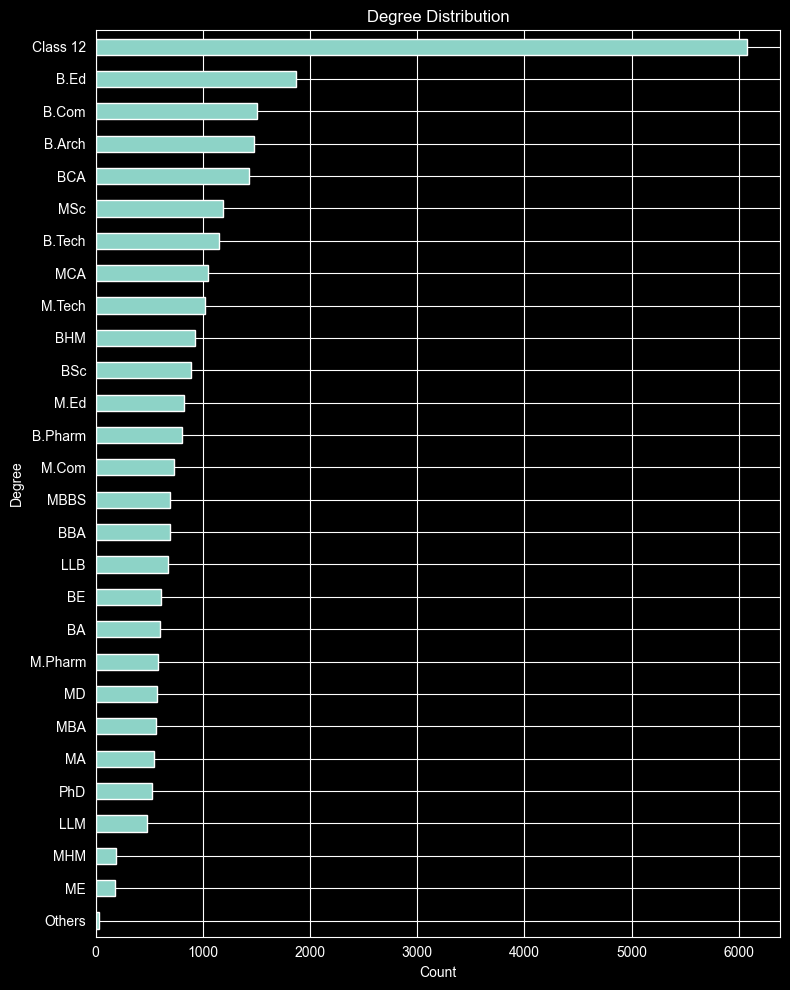

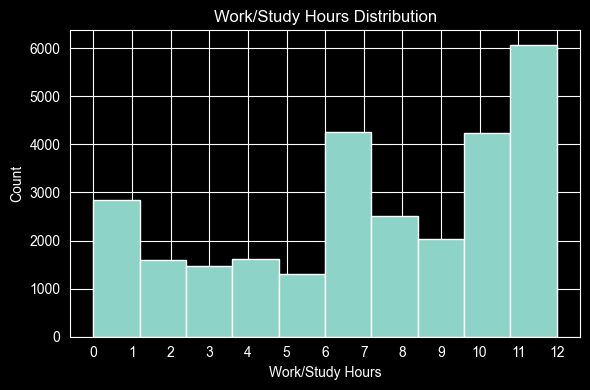

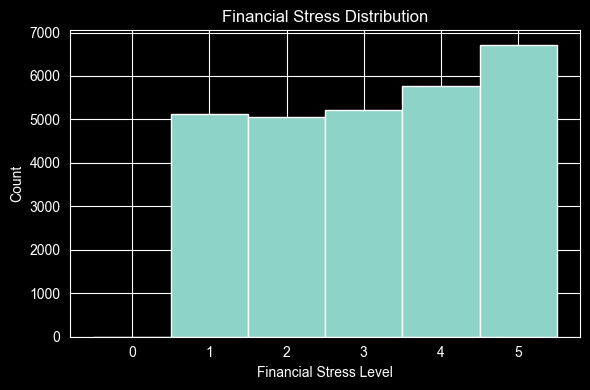

In [25]:
# Academic pressure distribution
plt.figure(figsize=(6,4))
plt.hist(df["Academic Pressure"], bins=6, range=(-0.5, 5.5))
plt.xticks(range(6))
plt.title("Academic Pressure Distribution")
plt.xlabel("Academic Pressure Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# CGPA distribution
bins = np.arange(4, 10.5, 0.5)
plt.figure(figsize=(6,4))
plt.hist(df["CGPA"], bins=bins)
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(4, 10)
plt.tight_layout()
plt.show()


# Study satisfaction distribution
plt.figure(figsize=(6,4))
plt.hist(df["Study Satisfaction"], bins=6, range=(-0.5, 5.5))
plt.xticks(range(6))
plt.title("Study Satisfaction Distribution")
plt.xlabel("Study Satisfaction Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Degree distribution
degree_counts = df["Degree"].value_counts().sort_values()
plt.figure(figsize=(8,10))
degree_counts.plot(kind="barh")
plt.title("Degree Distribution")
plt.xlabel("Count")
plt.ylabel("Degree")
plt.tight_layout()
plt.show()


# Work/Study hours distribution
plt.figure(figsize=(6,4))
plt.hist(df["Work/Study Hours"],bins=10,range=(0, 12))
plt.title("Work/Study Hours Distribution")
plt.xlabel("Work/Study Hours")
plt.ylabel("Count")
plt.xticks(range(0, 13))
plt.tight_layout()
plt.show()


# Financial stress distribution
plt.figure(figsize=(6,4))
plt.hist(df["Financial Stress"], bins=6, range=(-0.5, 5.5))
plt.xticks(range(6))
plt.title("Financial Stress Distribution")
plt.xlabel("Financial Stress Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



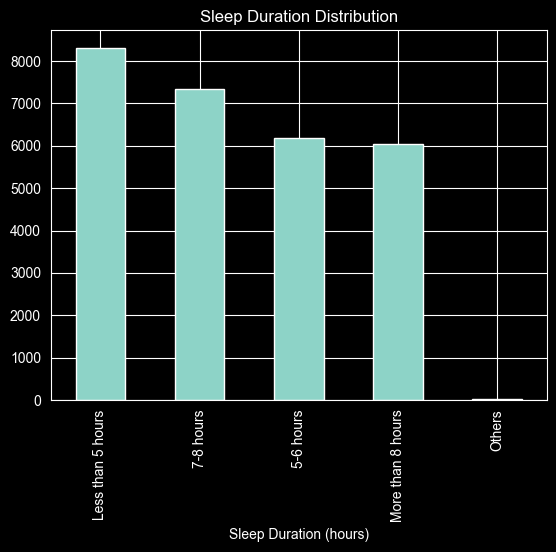

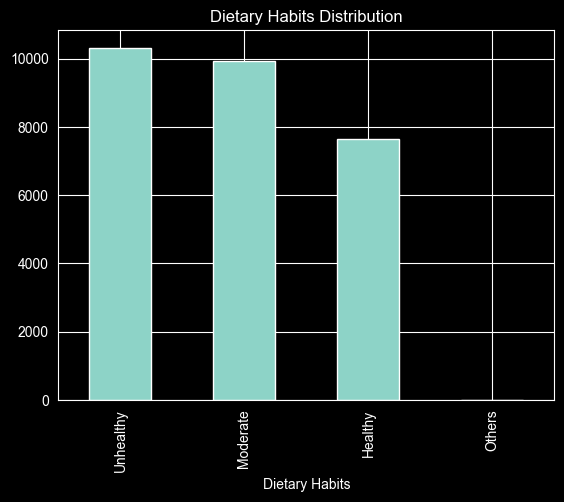

In [20]:
# Sleep duration distribution
df["Sleep Duration"].value_counts().plot(kind="bar")
plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration (hours)")
plt.show()


# Dietary habits distribution
df["Dietary Habits"].value_counts().plot(kind="bar")
plt.title("Dietary Habits Distribution")
plt.xlabel("Dietary Habits")
plt.show()

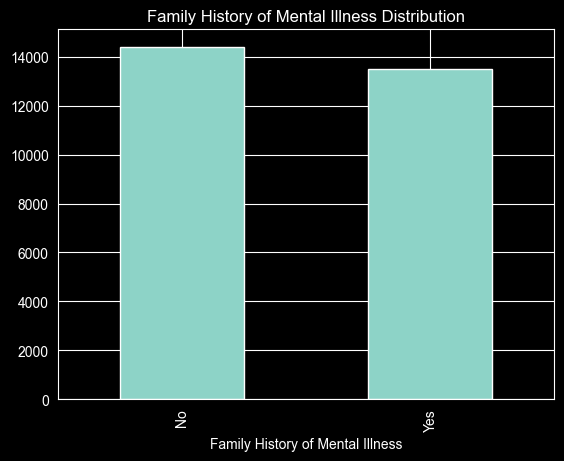

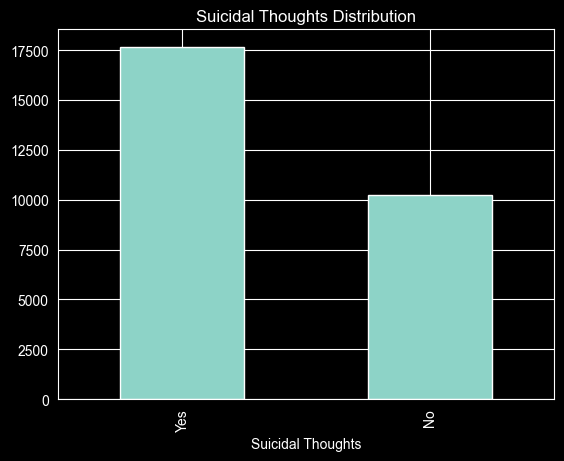

In [27]:
# Family history of mental illness distribution
df["Family History of Mental Illness"].value_counts().plot(kind="bar")
plt.title("Family History of Mental Illness Distribution")
plt.xlabel("Family History of Mental Illness")
plt.show()


# Suicidal thoughts distribution
df["Have you ever had suicidal thoughts ?"].value_counts().plot(kind="bar")
plt.title("Suicidal Thoughts Distribution")
plt.xlabel("Suicidal Thoughts")
plt.show()

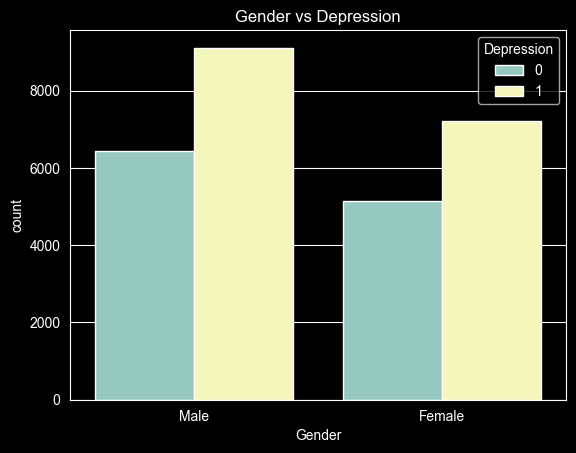

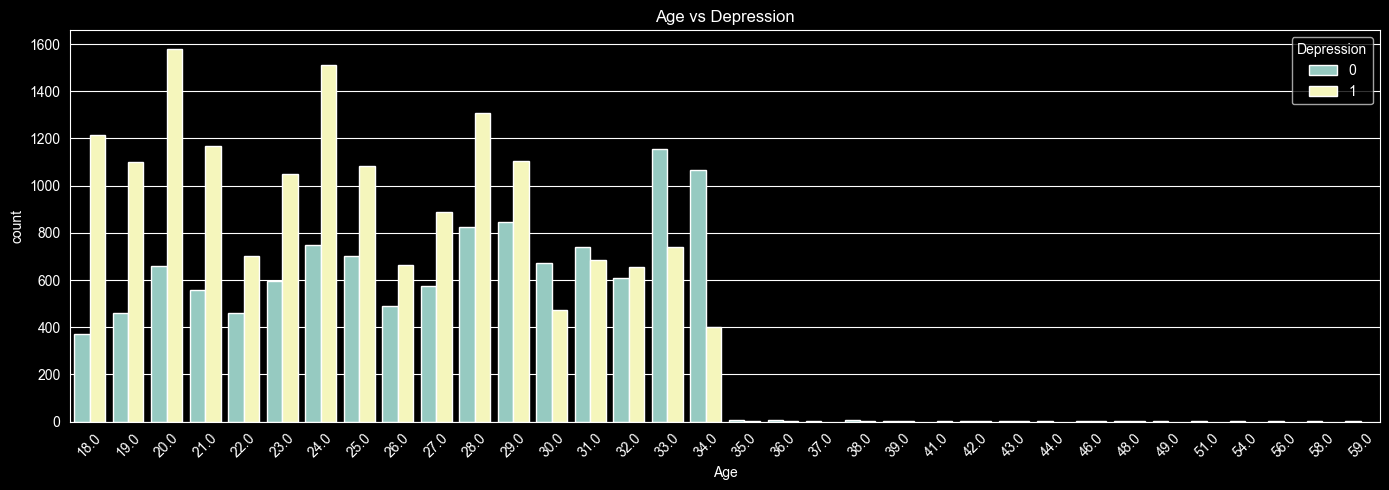

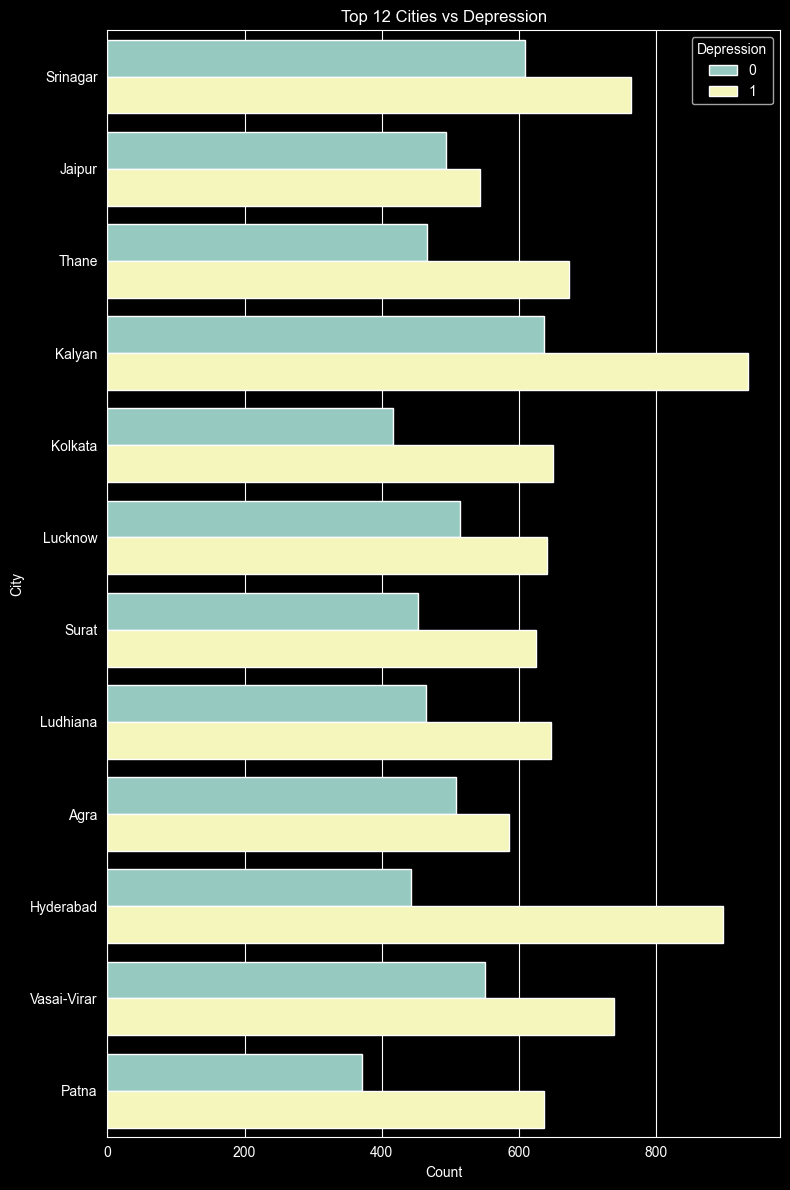

In [6]:
# Relationship with outcome
sns.countplot(x="Gender", hue="Depression", data=df)
plt.title("Gender vs Depression")
plt.show()


plt.figure(figsize=(14,5))
sns.countplot(x="Age", hue="Depression", data=df)
plt.title("Age vs Depression")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,12))
top_cities = df["City"].value_counts().head(12).index
sns.countplot(
    y="City",
    hue="Depression",
    data=df[df["City"].isin(top_cities)]
)
plt.title("Top 12 Cities vs Depression")
plt.xlabel("Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()

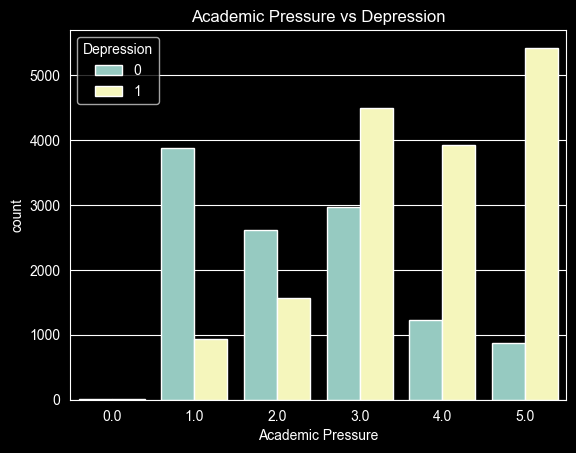

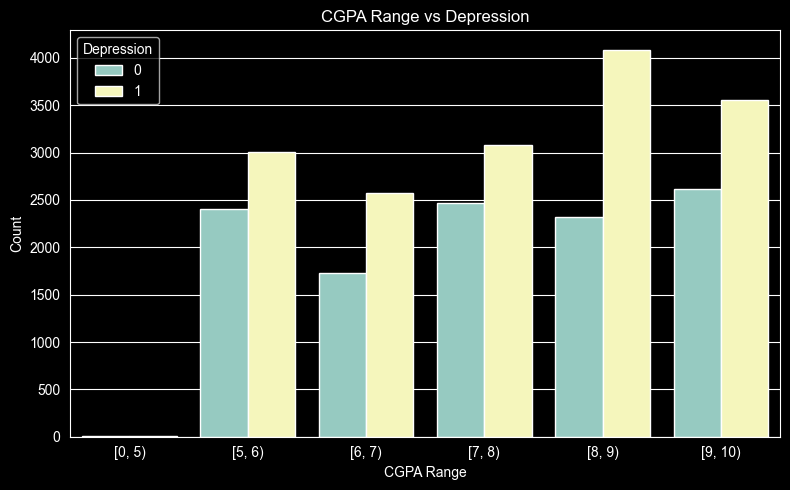

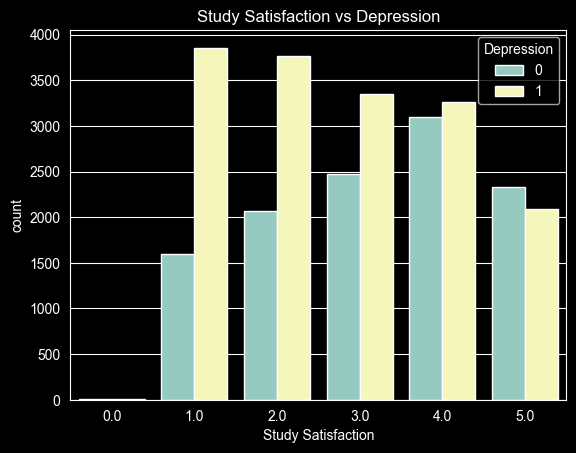

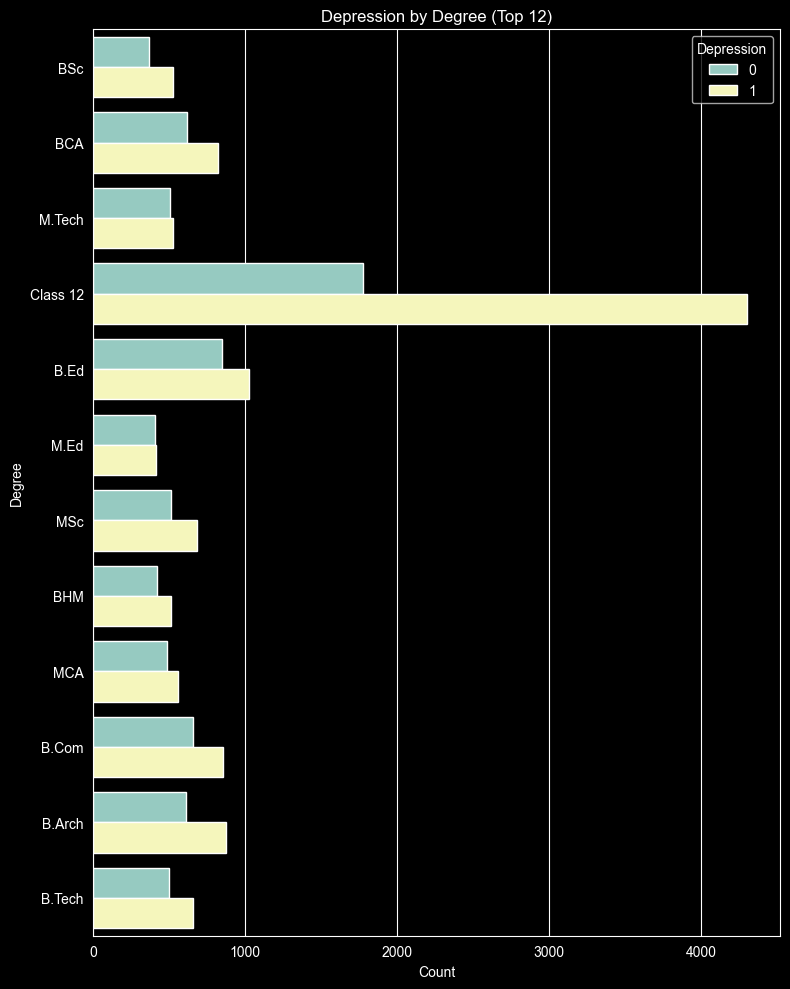

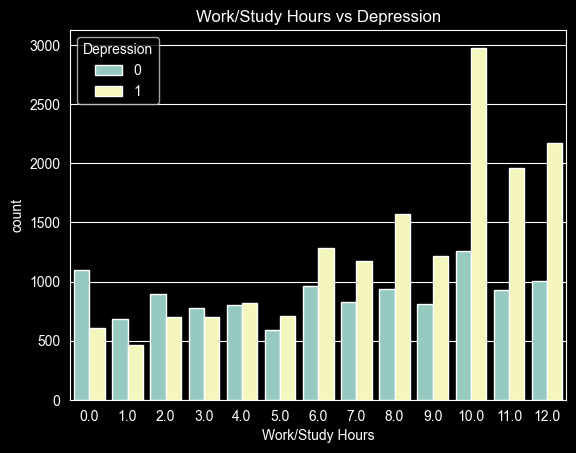

In [13]:
sns.countplot(x="Academic Pressure", hue="Depression", data=df)
plt.title("Academic Pressure vs Depression")
plt.show()


df["CGPA_bin"] = pd.cut(df["CGPA"], bins=[0, 5, 6, 7, 8, 9, 10], right=False)
plt.figure(figsize=(8,5))
sns.countplot(x="CGPA_bin", hue="Depression", data=df)
plt.title("CGPA Range vs Depression")
plt.xlabel("CGPA Range")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


sns.countplot(x="Study Satisfaction", hue="Depression", data=df)
plt.title("Study Satisfaction vs Depression")
plt.show()


plt.figure(figsize=(8,10))
top_degrees = df["Degree"].value_counts().head(12).index
sns.countplot(
    y="Degree",
    hue="Depression",
    data=df[df["Degree"].isin(top_degrees)]
)
plt.title("Depression by Degree (Top 12)")
plt.xlabel("Count")
plt.ylabel("Degree")
plt.tight_layout()
plt.show()


sns.countplot(x="Work/Study Hours", hue="Depression", data=df)
plt.title("Work/Study Hours vs Depression")
plt.show()

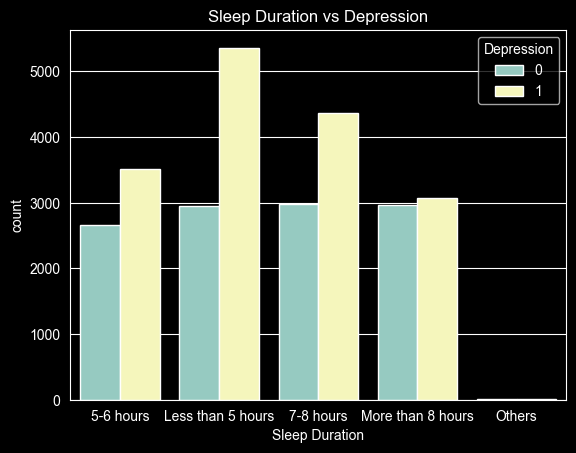

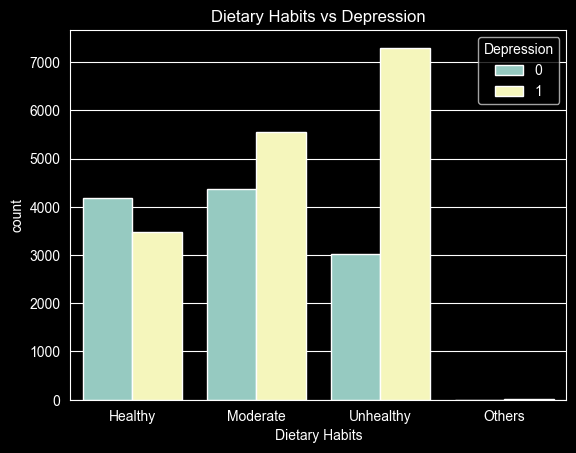

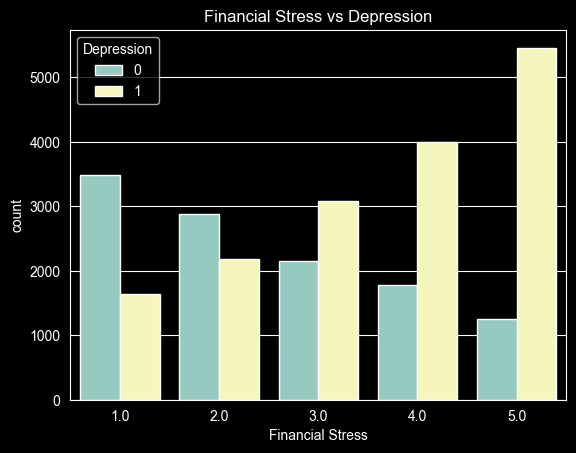

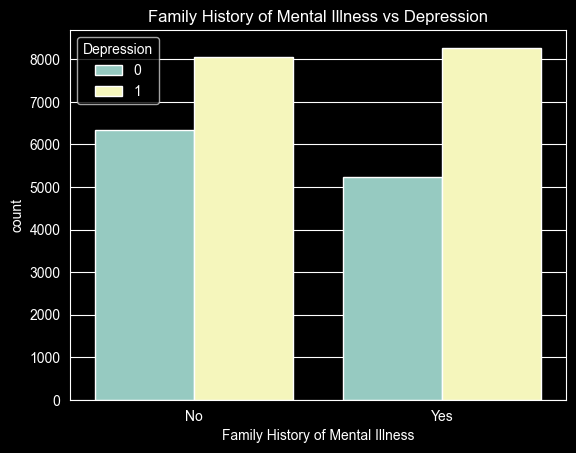

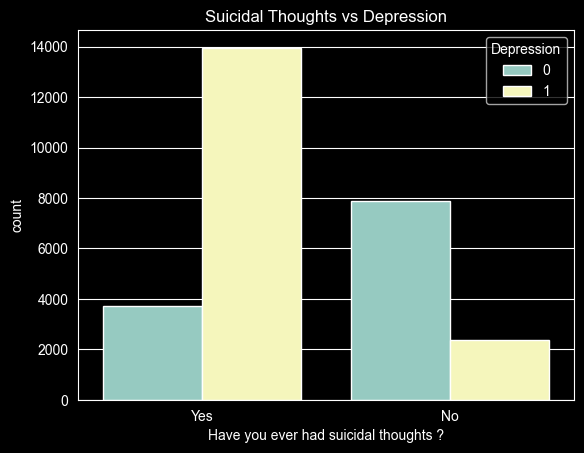

In [18]:
sns.countplot(x="Sleep Duration", hue="Depression", data=df)
plt.title("Sleep Duration vs Depression")
plt.show()


sns.countplot(x="Dietary Habits", hue="Depression", data=df)
plt.title("Dietary Habits vs Depression")
plt.show()


sns.countplot(x="Financial Stress", hue="Depression", data=df)
plt.title("Financial Stress vs Depression")
plt.show()


sns.countplot(x="Family History of Mental Illness", hue="Depression", data=df)
plt.title("Family History of Mental Illness vs Depression")
plt.show()


sns.countplot(x="Have you ever had suicidal thoughts ?", hue="Depression", data=df)
plt.title("Suicidal Thoughts vs Depression")
plt.show()

In [19]:
# Preprocessing for BN
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../../data/raw/student_mental_health/student_depression.csv")
display(df.head())
print("Shape:", df.shape)
display(df.dtypes)
display(df.columns)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


Shape: (27901, 18)


id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness             str
Depression                                 int64
dtype: object

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [20]:
OUT_BN = "../data/processed/student_depression_bn_clean.csv"

# Helper functions
def strip_strings(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip()

def normalize_missing_tokens(s: pd.Series) -> pd.Series:
    x = strip_strings(s).str.lower()
    return x.replace({"": pd.NA, "nan": pd.NA, "na": pd.NA, "n/a": pd.NA, "none": pd.NA, "null": pd.NA})

def clean_age(s: pd.Series, min_age=12, max_age=100) -> pd.Series:
    a = pd.to_numeric(s, errors="coerce")
    return a.where((a >= min_age) & (a <= max_age), np.nan)

def normalize_gender(s: pd.Series) -> pd.Series:
    x = normalize_missing_tokens(s)
    mapping = {
        "Male": "male", "m": "male", "man": "male", "boy": "male", "male": "male",
        "Female": "female", "f": "female", "woman": "female", "girl": "female", "female":"female"
    }
    return x.map(mapping)

def normalize_yes_no(s: pd.Series) -> pd.Series:
    x = normalize_missing_tokens(s)
    yes = {"yes", "y", "true", "1"}
    no = {"no", "n", "false", "0"}
    return x.map(lambda v: "Yes" if v in yes else ("No" if v in no else pd.NA))

def normalize_yes_no_maybe(s: pd.Series) -> pd.Series:
    x = normalize_missing_tokens(s)
    mapping = {
        "yes": "Yes", "y": "Yes", "true": "Yes", "1": "Yes",
        "no": "No", "n": "No", "false": "No", "0": "No",
        "maybe": "Maybe", "not sure": "Maybe", "unsure": "Maybe",
    }
    return x.map(mapping)

def try_numeric(s: pd.Series) -> pd.Series:
    # Convert if numeric; otherwise keep as string
    converted = pd.to_numeric(s, errors="coerce")
    # If conversion produces too many NaNs, keep original
    if converted.notna().mean() < 0.6:
        return s
    return converted

SLEEP_ORDER = ["Less than 5 hours", "5-6 hours", "7-8 hours", "More than 8 hours", "Others"]

def normalize_sleep_duration(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip().str.lower()
    x = x.replace({"": pd.NA, "nan": pd.NA, "na": pd.NA})

    mapping = {
        "less than 5 hours": "Less than 5 hours",
        "<5 hours": "Less than 5 hours",
        "5-6 hours": "5-6 hours",
        "5 to 6 hours": "5-6 hours",
        "7-8 hours": "7-8 hours",
        "7 to 8 hours": "7-8 hours",
        "more than 8 hours": "More than 8 hours",
        ">8 hours": "More than 8 hours",
        "others": "Others",
        "other": "Others",
    }
    return x.map(mapping)

DIET_CATS = ["Healthy", "Moderate", "Unhealthy", "Others"]

def normalize_dietary_habits(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip().str.lower()
    x = x.replace({"": pd.NA, "nan": pd.NA, "na": pd.NA})

    mapping = {
        "healthy": "Healthy",
        "moderate": "Moderate",
        "unhealthy": "Unhealthy",
        "others": "Others",
        "other": "Others",
    }
    return x.map(mapping)

# Start BN preprocessing
df_bn = df.copy()

# Standardize column names
df_bn.columns = [c.strip() for c in df_bn.columns]

# Strip whitespace
for col in df_bn.select_dtypes(include=["object"]).columns:
    df_bn[col] = strip_strings(df_bn[col])

# Drop irrelevant columns
for col in ["index", "Index", "id", "ID", "timestamp", "Timestamp"]:
    if col in df_bn.columns:
        df_bn = df_bn.drop(columns=[col])

# Clean age if present (handles "Age" or "age")
for col in ["Age", "age"]:
    if col in df_bn.columns:
        df_bn[col] = clean_age(df_bn[col])

# Normalize gender
for col in ["Gender", "gender"]:
    if col in df_bn.columns:
        df_bn[col] = normalize_gender(df_bn[col])

# Normalize common mental-health target columns
target_like_cols = [
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness",
    "Depression"
]
for col in target_like_cols:
    if col in df_bn.columns:
        df_bn[col] = normalize_yes_no(df_bn[col])

# Convert numeric-like columns safely
numeric_candidates = [
    "CGPA", "cgpa", "Work/Study Hours",
    "Academic Pressure", "academic_pressure",
    "Work Pressure", "work_pressure",
    "Financial Stress", "financial_stress",
    "Study Satisfaction", "study_satisfaction",
    "Job Satisfaction", "job_satisfaction"
]
for col in numeric_candidates:
    if col in df_bn.columns:
        df_bn[col] = try_numeric(df_bn[col])

# Normalize sleep duration
if "Sleep Duration" in df_bn.columns:
    df_bn["Sleep Duration"] = normalize_sleep_duration(df_bn["Sleep Duration"])
    df_bn["Sleep Duration"] = pd.Categorical(
        df_bn["Sleep Duration"],
        categories=SLEEP_ORDER,
        ordered=True
    )

# Normalize dietary habits
if "Dietary Habits" in df_bn.columns:
    df_bn["Dietary Habits"] = normalize_dietary_habits(df_bn["Dietary Habits"])
    df_bn["Dietary Habits"] = pd.Categorical(
        df_bn["Dietary Habits"],
        categories=DIET_CATS,
        ordered=False
    )

# Standardize missing-token strings to NaN for all string columns
for col in df_bn.select_dtypes(include=["object", "string"]).columns:
    df_bn[col] = normalize_missing_tokens(df_bn[col])

# Save BN-clean dataset
df_bn.to_csv(OUT_BN, index=False)

print("Saved BN dataset to:", OUT_BN)
display(df_bn.head())
print("Shape:", df_bn.shape)

C:\Users\Diana\AppData\Local\Temp\ipykernel_18344\3981704915.py:88: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_bn.select_dtypes(include=["object"]).columns:


Saved BN dataset to: ../data/processed/student_depression_bn_clean.csv


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,male,33.0,visakhapatnam,student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,b.pharm,yes,3.0,1.0,no,yes
1,female,24.0,bangalore,student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,bsc,no,3.0,2.0,yes,no
2,male,31.0,srinagar,student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,ba,no,9.0,1.0,yes,no
3,female,28.0,varanasi,student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,bca,yes,4.0,5.0,yes,yes
4,female,25.0,jaipur,student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,m.tech,yes,1.0,1.0,no,no


Shape: (27901, 17)


In [21]:
OUT_ML = "../data/processed/student_depression_ml.csv"

def mode_impute(series: pd.Series) -> pd.Series:
    if series.dropna().empty: # if a column is entirely missing, don’t try to compute a mode
        return series
    return series.fillna(series.mode(dropna=True).iloc[0]) # finds the most frequent value (mode),
                                                           # replaces missing values with that mode

def median_impute(series: pd.Series) -> pd.Series:
    return series.fillna(series.median()) # replaces missing values with the column’s median

# Start from BN-cleaned data
df_ml = df_bn.copy()

# Ensure categorical dtypes behave consistently
for col in df_ml.columns:
    if str(df_ml[col].dtype) == "category":
        df_ml[col] = df_ml[col].astype("string") # some columns are set to categorical for BN
                                                 # for ML one-hot encoding, convert them to string

# For every column that has missing values
#  create a new column
#  set it to 1 if the original value was missing, else 0
#  store its name in missing_indicators
missing_indicators = []
for col in df_ml.columns:
    if df_ml[col].isna().any():
        ind_col = f"{col}__missing"
        df_ml[ind_col] = df_ml[col].isna().astype(int)
        missing_indicators.append(ind_col)

# Impute numeric columns with median
num_cols = df_ml.select_dtypes(include=["number"]).columns
for col in num_cols:
    df_ml[col] = median_impute(df_ml[col])

# Impute categorical columns with mode
cat_cols = [c for c in df_ml.columns if c not in num_cols and c not in missing_indicators]
for col in cat_cols:
    df_ml[col] = mode_impute(df_ml[col])

# One-hot encode categoricals, turns each categorical column into multiple 0/1 dummy columns
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

# Make all dummy columns 0/1 instead of True/False
df_ml = df_ml.astype(int)

# Save ML dataset
df_ml.to_csv(OUT_ML, index=False)

print("Saved ML dataset to:", OUT_ML)
display(df_ml.head())
print("Shape:", df_ml.shape)


Saved ML dataset to: ../data/processed/student_depression_ml.csv


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Financial Stress__missing,Gender_male,City_agra,City_ahmedabad,City_bangalore,City_bhavna,City_bhopal,City_chennai,City_city,City_delhi,City_faridabad,City_gaurav,City_ghaziabad,City_harsh,City_harsha,City_hyderabad,City_indore,City_jaipur,City_kalyan,City_kanpur,City_khaziabad,City_kibara,City_kolkata,City_less delhi,City_less than 5 kalyan,City_lucknow,City_ludhiana,City_m.com,City_m.tech,City_me,City_meerut,City_mihir,City_mira,City_mumbai,City_nagpur,City_nalini,City_nalyan,City_nandini,City_nashik,City_patna,City_pune,City_rajkot,City_rashi,City_reyansh,City_saanvi,City_srinagar,City_surat,City_thane,City_vaanya,City_vadodara,City_varanasi,City_vasai-virar,City_visakhapatnam,Profession_chef,Profession_civil engineer,Profession_content writer,Profession_digital marketer,Profession_doctor,Profession_educational consultant,Profession_entrepreneur,Profession_lawyer,Profession_manager,Profession_pharmacist,Profession_student,Profession_teacher,Profession_ux/ui designer,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Degree_b.com,Degree_b.ed,Degree_b.pharm,Degree_b.tech,Degree_ba,Degree_bba,Degree_bca,Degree_be,Degree_bhm,Degree_bsc,Degree_class 12,Degree_llb,Degree_llm,Degree_m.com,Degree_m.ed,Degree_m.pharm,Degree_m.tech,Degree_ma,Degree_mba,Degree_mbbs,Degree_mca,Degree_md,Degree_me,Degree_mhm,Degree_msc,Degree_others,Degree_phd,Have you ever had suicidal thoughts ?_yes,Family History of Mental Illness_yes,Depression_yes
0,33,5,0,8,2,0,3,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,24,2,0,5,5,0,3,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,31,3,0,7,5,0,9,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,28,3,0,5,2,0,4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
4,25,4,0,8,3,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0


Shape: (27901, 111)
